# Comprehensive Model Comparison: HyD-Fake vs UPFD Baselines

This notebook compares all models (HyD-Fake + UPFD baselines) across:
- **Datasets**: PolitiFact, GossipCop
- **Encoders**: SBERT (384D), BERT (768D)
- **Baselines**: BiGCN, GCNFN, GNN, GNNCLNet, GAT, GCN, SAGE
- **Metrics**: F1, Accuracy, Precision, Recall, AUC-ROC

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Define paths
OUTPUT_DIR = Path('../outputs')
DATASETS = ['politifact', 'gossipcop']
ENCODERS = ['sbert', 'bert']

# Define all models
BASELINE_MODELS = ['bigcn', 'gcnfn', 'gnn', 'gnncl', 'gat', 'gcn', 'sage']
HYBRID_MODELS = ['hyd_fake']
ALL_MODELS = HYBRID_MODELS + BASELINE_MODELS

print(f"Output directory: {OUTPUT_DIR}")
print(f"Datasets: {DATASETS}")
print(f"Encoders: {ENCODERS}")
print(f"Models: {ALL_MODELS}")

Output directory: ..\outputs
Datasets: ['politifact', 'gossipcop']
Encoders: ['sbert', 'bert']
Models: ['hyd_fake', 'bigcn', 'gcnfn', 'gnn', 'gnncl', 'gat', 'gcn', 'sage']


## 1. Load Results from All Models

In [3]:
def load_metrics(model_name, encoder, dataset):
    """
    Load metrics for a specific model, encoder, and dataset.
    Returns a dict or None if not found.
    """
    if model_name == 'hyd_fake':
        # HyD-Fake has encoder-specific directories: hyd_fake_{encoder}/{dataset}/
        path = OUTPUT_DIR / f'hyd_fake' /f'hyd_fake_{encoder}' / dataset / 'metrics_hyd_fake_final.json'
    else:
        # Baselines: baselines_{encoder}/{model}/{dataset}/
        path = OUTPUT_DIR / f'baselines_{encoder}' / model_name / dataset / f'metrics_{model_name}_final.json'
    
    if path.exists():
        try:
            with open(path, 'r') as f:
                return json.load(f)
        except Exception as e:
            print(f"  Error loading {path}: {e}")
            return None
    return None

# Load all metrics
all_results = []

for dataset in DATASETS:
    for encoder in ENCODERS:
        for model in ALL_MODELS:
            metrics = load_metrics(model, encoder, dataset)
            if metrics is not None:
                row = {
                    'model': model,
                    'encoder': encoder,
                    'dataset': dataset,
                    'f1': metrics.get('f1', None),
                    'accuracy': metrics.get('accuracy', None),
                    'precision': metrics.get('precision', None),
                    'recall': metrics.get('recall', None),
                    'auc': metrics.get('auc_roc', metrics.get('auc', None)),
                }
                all_results.append(row)
                print(f"Loaded {model:10s} | {encoder:5s} | {dataset:10s} | F1: {row['f1']:.4f}")
            else:
                print(f"Missing {model:10s} | {encoder:5s} | {dataset:10s}")

# Create DataFrame
df_results = pd.DataFrame(all_results)
print(f"\nLoaded {len(df_results)} model results")
print(f"\nDataFrame shape: {df_results.shape}")
print(f"Models found: {df_results['model'].unique()}")
df_results.head(10)

Loaded hyd_fake   | sbert | politifact | F1: 0.8596
Loaded bigcn      | sbert | politifact | F1: 0.8155
Loaded gcnfn      | sbert | politifact | F1: 0.7273
Loaded gnn        | sbert | politifact | F1: 0.7843
Loaded gnncl      | sbert | politifact | F1: 0.6766
Loaded gat        | sbert | politifact | F1: 0.6038
Loaded gcn        | sbert | politifact | F1: 0.6881
Loaded sage       | sbert | politifact | F1: 0.7900
Loaded hyd_fake   | bert  | politifact | F1: 0.8378
Loaded bigcn      | bert  | politifact | F1: 0.8641
Loaded gcnfn      | bert  | politifact | F1: 0.6766
Loaded gnn        | bert  | politifact | F1: 0.7745
Loaded gnncl      | bert  | politifact | F1: 0.7241
Loaded gat        | bert  | politifact | F1: 0.7245
Loaded gcn        | bert  | politifact | F1: 0.7716
Loaded sage       | bert  | politifact | F1: 0.7980
Loaded hyd_fake   | sbert | gossipcop  | F1: 0.9585
Loaded bigcn      | sbert | gossipcop  | F1: 0.9502
Loaded gcnfn      | sbert | gossipcop  | F1: 0.9715
Loaded gnn  

,model,encoder,dataset,f1,accuracy,precision,recall,auc
0,hyd_fake,sbert,politifact,0.859649,0.855204,0.852174,0.867257,0.919207
1,bigcn,sbert,politifact,0.815534,0.828054,0.903226,0.743363,0.927483
2,gcnfn,sbert,politifact,0.727273,0.742081,0.791667,0.672566,0.840708
3,gnn,sbert,politifact,0.784314,0.800905,0.879121,0.707965,0.914782
4,gnncl,sbert,politifact,0.676647,0.511312,0.511312,1.000000,0.416912
5,gat,sbert,politifact,0.603774,0.524887,0.526316,0.707965,0.540069
6,gcn,sbert,politifact,0.688103,0.561086,0.540404,0.946903,0.707063
7,sage,sbert,politifact,0.790000,0.809955,0.908046,0.699115,0.919535
8,hyd_fake,bert,politifact,0.837838,0.837104,0.853211,0.823009,0.920108
9,bigcn,bert,politifact,0.864078,0.873303,0.956989,0.787611,0.928138


## 2. Summary Statistics by Dataset and Encoder

In [4]:
# Overall summary
print("="*100)
print("OVERALL METRICS SUMMARY")
print("="*100)
print(df_results[['model', 'encoder', 'dataset', 'f1', 'accuracy', 'precision', 'recall', 'auc']].to_string(index=False))
print()

OVERALL METRICS SUMMARY
   model encoder    dataset       f1  accuracy  precision   recall      auc
hyd_fake   sbert politifact 0.859649  0.855204   0.852174 0.867257 0.919207
   bigcn   sbert politifact 0.815534  0.828054   0.903226 0.743363 0.927483
   gcnfn   sbert politifact 0.727273  0.742081   0.791667 0.672566 0.840708
     gnn   sbert politifact 0.784314  0.800905   0.879121 0.707965 0.914782
   gnncl   sbert politifact 0.676647  0.511312   0.511312 1.000000 0.416912
     gat   sbert politifact 0.603774  0.524887   0.526316 0.707965 0.540069
     gcn   sbert politifact 0.688103  0.561086   0.540404 0.946903 0.707063
    sage   sbert politifact 0.790000  0.809955   0.908046 0.699115 0.919535
hyd_fake    bert politifact 0.837838  0.837104   0.853211 0.823009 0.920108
   bigcn    bert politifact 0.864078  0.873303   0.956989 0.787611 0.928138
   gcnfn    bert politifact 0.676647  0.511312   0.511312 1.000000 0.486234
     gnn    bert politifact 0.774510  0.791855   0.868132 0.6991

## 3. F1 Score Comparison by Dataset and Encoder

In [5]:
# Create comparison tables
for dataset in DATASETS:
    print(f"\n{'='*100}")
    print(f"{dataset.upper()} - F1 SCORE COMPARISON")
    print(f"{'='*100}")
    
    df_subset = df_results[df_results['dataset'] == dataset]
    
    # Pivot: models × encoders
    f1_pivot = df_subset.pivot_table(
        index='model', 
        columns='encoder', 
        values='f1', 
        aggfunc='first'
    )
    
    # Add average
    f1_pivot['avg'] = f1_pivot.mean(axis=1)
    f1_pivot = f1_pivot.sort_values('avg', ascending=False)
    
    print(f1_pivot.to_string())
    print()


POLITIFACT - F1 SCORE COMPARISON
encoder       bert     sbert       avg
model                                 
hyd_fake  0.837838  0.859649  0.848743
bigcn     0.864078  0.815534  0.839806
sage      0.798030  0.790000  0.794015
gnn       0.774510  0.784314  0.779412
gcn       0.771574  0.688103  0.729838
gcnfn     0.676647  0.727273  0.701960
gnncl     0.724138  0.676647  0.700392
gat       0.724490  0.603774  0.664132


GOSSIPCOP - F1 SCORE COMPARISON
encoder       bert     sbert       avg
model                                 
sage      0.976889  0.976973  0.976931
gnn       0.970944  0.975395  0.973169
gcn       0.970165  0.975280  0.972722
gat       0.976973  0.967085  0.972029
gcnfn     0.971846  0.971473  0.971659
gnncl     0.969602  0.972172  0.970887
hyd_fake  0.963195  0.958453  0.960824
bigcn     0.960547  0.950210  0.955378



## 4. All Metrics by Dataset and Encoder

In [6]:
# Detailed comparison for each metric
metrics_to_compare = ['f1', 'accuracy', 'precision', 'recall', 'auc']

for dataset in DATASETS:
    print(f"\n{'='*100}")
    print(f"{dataset.upper()} - DETAILED METRICS")
    print(f"{'='*100}")
    
    df_subset = df_results[df_results['dataset'] == dataset]
    
    for encoder in ENCODERS:
        print(f"\n{'-'*100}")
        print(f"Encoder: {encoder.upper()}")
        print(f"{'-'*100}")
        
        df_encoder = df_subset[df_subset['encoder'] == encoder].copy()
        
        # Sort by F1
        df_encoder = df_encoder.sort_values('f1', ascending=False)
        
        # Display top models
        print(df_encoder[['model', 'f1', 'accuracy', 'precision', 'recall', 'auc']].to_string(index=False))
        print()


POLITIFACT - DETAILED METRICS

----------------------------------------------------------------------------------------------------
Encoder: SBERT
----------------------------------------------------------------------------------------------------
   model       f1  accuracy  precision   recall      auc
hyd_fake 0.859649  0.855204   0.852174 0.867257 0.919207
   bigcn 0.815534  0.828054   0.903226 0.743363 0.927483
    sage 0.790000  0.809955   0.908046 0.699115 0.919535
     gnn 0.784314  0.800905   0.879121 0.707965 0.914782
   gcnfn 0.727273  0.742081   0.791667 0.672566 0.840708
     gcn 0.688103  0.561086   0.540404 0.946903 0.707063
   gnncl 0.676647  0.511312   0.511312 1.000000 0.416912
     gat 0.603774  0.524887   0.526316 0.707965 0.540069


----------------------------------------------------------------------------------------------------
Encoder: BERT
----------------------------------------------------------------------------------------------------
   model       f1  a

## 5. HyD-Fake vs Best Baseline for Each Dataset+Encoder

In [7]:
print("\n" + "="*100)
print("HYD-FAKE VS BEST BASELINE")
print("="*100)

for dataset in DATASETS:
    print(f"\n{'-'*100}")
    print(f"{dataset.upper()}")
    print(f"{'-'*100}")
    
    df_dataset = df_results[df_results['dataset'] == dataset]
    
    for encoder in ENCODERS:
        print(f"\n  Encoder: {encoder.upper()}")
        
        df_encoder = df_dataset[df_dataset['encoder'] == encoder]
        
        hyd_fake = df_encoder[df_encoder['model'] == 'hyd_fake'].iloc[0] if len(df_encoder[df_encoder['model'] == 'hyd_fake']) > 0 else None
        baselines = df_encoder[df_encoder['model'] != 'hyd_fake'].sort_values('f1', ascending=False)
        
        if hyd_fake is not None and len(baselines) > 0:
            best_baseline = baselines.iloc[0]
            
            f1_diff = hyd_fake['f1'] - best_baseline['f1']
            f1_pct = (f1_diff / best_baseline['f1']) * 100
            
            print(f"    HyD-Fake:        F1={hyd_fake['f1']:.4f} | Acc={hyd_fake['accuracy']:.4f} | AUC={hyd_fake['auc']:.4f}")
            print(f"    Best Baseline:   F1={best_baseline['f1']:.4f} ({best_baseline['model'].upper()})")
            print(f"    Improvement:     ΔF1={f1_diff:+.4f} ({f1_pct:+.2f}%)")
        else:
            print(f"    Data not available")

print()


HYD-FAKE VS BEST BASELINE

----------------------------------------------------------------------------------------------------
POLITIFACT
----------------------------------------------------------------------------------------------------

  Encoder: SBERT
    HyD-Fake:        F1=0.8596 | Acc=0.8552 | AUC=0.9192
    Best Baseline:   F1=0.8155 (BIGCN)
    Improvement:     ΔF1=+0.0441 (+5.41%)

  Encoder: BERT
    HyD-Fake:        F1=0.8378 | Acc=0.8371 | AUC=0.9201
    Best Baseline:   F1=0.8641 (BIGCN)
    Improvement:     ΔF1=-0.0262 (-3.04%)

----------------------------------------------------------------------------------------------------
GOSSIPCOP
----------------------------------------------------------------------------------------------------

  Encoder: SBERT
    HyD-Fake:        F1=0.9585 | Acc=0.9584 | AUC=0.9853
    Best Baseline:   F1=0.9770 (SAGE)
    Improvement:     ΔF1=-0.0185 (-1.90%)

  Encoder: BERT
    HyD-Fake:        F1=0.9632 | Acc=0.9631 | AUC=0.9892
    Be

## 6. Encoder Effect Analysis (SBERT vs BERT)

In [8]:
print("\n" + "="*100)
print("ENCODER COMPARISON: SBERT vs BERT")
print("="*100)

for dataset in DATASETS:
    print(f"\n{'-'*100}")
    print(f"{dataset.upper()}")
    print(f"{'-'*100}")
    
    df_dataset = df_results[df_results['dataset'] == dataset]
    
    sbert_results = df_dataset[df_dataset['encoder'] == 'sbert'].set_index('model')
    bert_results = df_dataset[df_dataset['encoder'] == 'bert'].set_index('model')
    
    comparison_data = []
    for model in sbert_results.index:
        if model in bert_results.index:
            sbert_f1 = sbert_results.loc[model, 'f1']
            bert_f1 = bert_results.loc[model, 'f1']
            diff = bert_f1 - sbert_f1
            pct = (diff / sbert_f1) * 100 if sbert_f1 > 0 else 0
            
            comparison_data.append({
                'model': model,
                'sbert_f1': sbert_f1,
                'bert_f1': bert_f1,
                'diff': diff,
                'pct_change': pct
            })
    
    df_encoder_comp = pd.DataFrame(comparison_data).sort_values('f1_diff' if 'f1_diff' in pd.DataFrame(comparison_data).columns else 'model')
    if len(df_encoder_comp) > 0:
        print(df_encoder_comp.to_string(index=False))
    else:
        print("  No comparable results found")

print()


ENCODER COMPARISON: SBERT vs BERT

----------------------------------------------------------------------------------------------------
POLITIFACT
----------------------------------------------------------------------------------------------------
   model  sbert_f1  bert_f1      diff  pct_change
   bigcn  0.815534 0.864078  0.048544    5.952381
     gat  0.603774 0.724490  0.120716   19.993622
     gcn  0.688103 0.771574  0.083471   12.130556
   gcnfn  0.727273 0.676647 -0.050626   -6.961078
     gnn  0.784314 0.774510 -0.009804   -1.250000
   gnncl  0.676647 0.724138  0.047491    7.018615
hyd_fake  0.859649 0.837838 -0.021811   -2.537231
    sage  0.790000 0.798030  0.008030    1.016400

----------------------------------------------------------------------------------------------------
GOSSIPCOP
----------------------------------------------------------------------------------------------------
   model  sbert_f1  bert_f1      diff  pct_change
   bigcn  0.950210 0.960547  0.010337 

## 7. Visualization: F1 Scores Across All Models

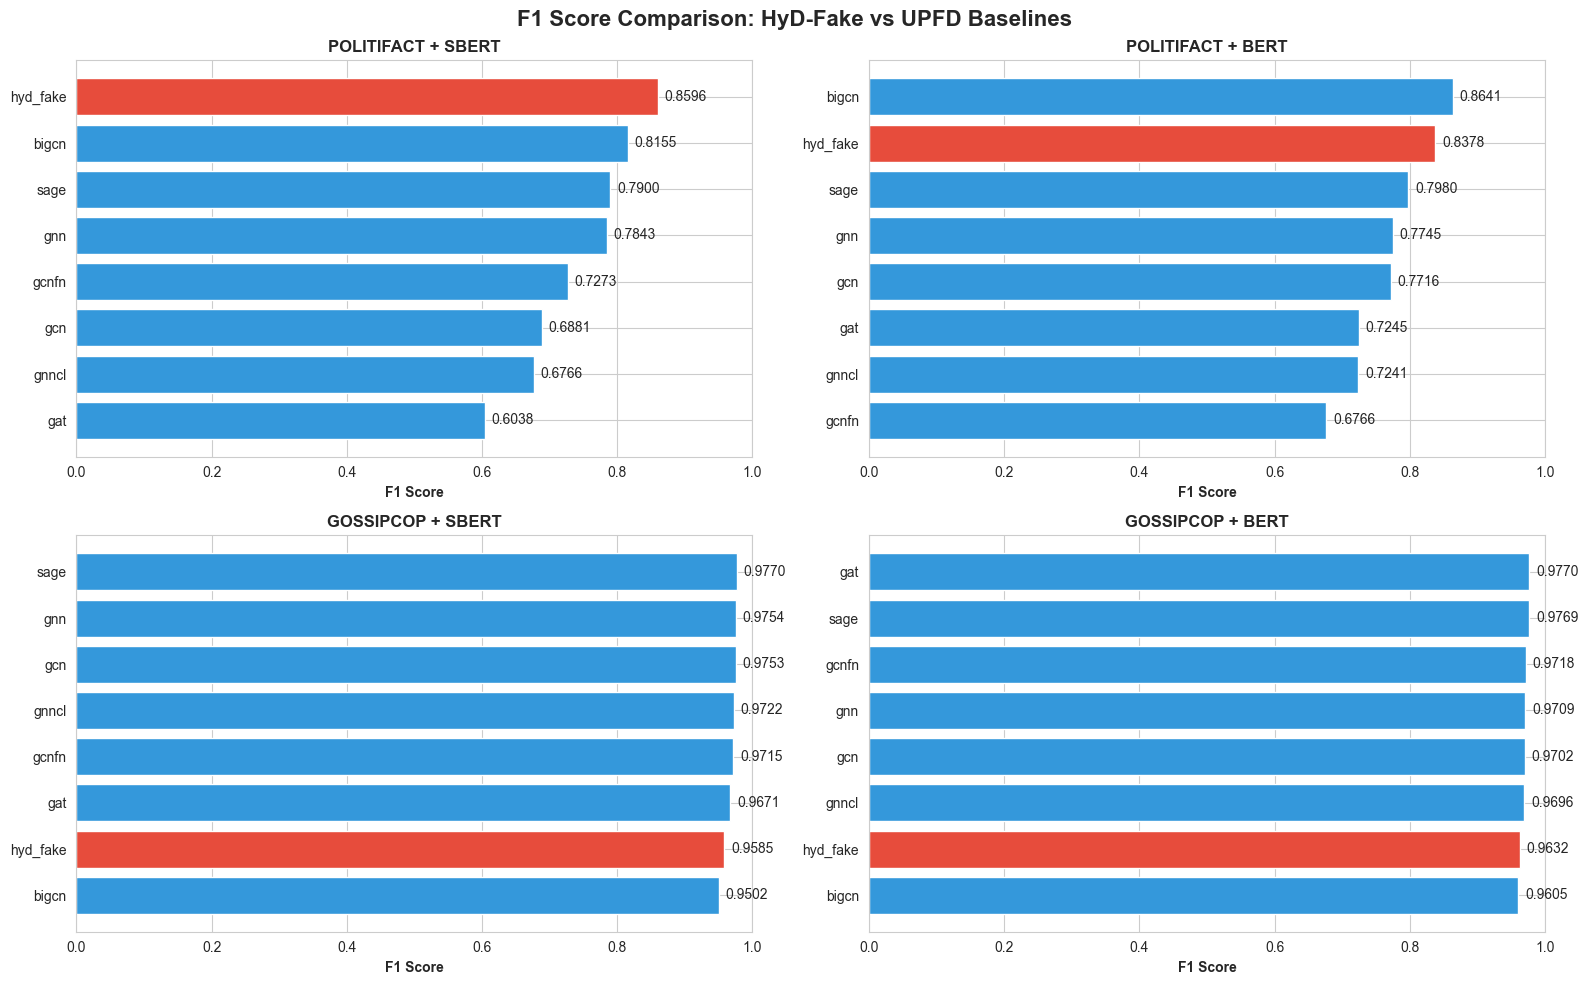

Saved: ../results/comparison_f1_scores.png


In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('F1 Score Comparison: HyD-Fake vs UPFD Baselines', fontsize=16, fontweight='bold')

for idx, (dataset, encoder) in enumerate([(d, e) for d in DATASETS for e in ENCODERS]):
    ax = axes[idx // 2, idx % 2]
    
    df_subset = df_results[
        (df_results['dataset'] == dataset) & 
        (df_results['encoder'] == encoder)
    ].sort_values('f1', ascending=True)
    
    if len(df_subset) > 0:
        # Highlight HyD-Fake in different color
        colors = ['#e74c3c' if m == 'hyd_fake' else '#3498db' for m in df_subset['model']]
        
        ax.barh(df_subset['model'], df_subset['f1'], color=colors)
        ax.set_xlabel('F1 Score', fontweight='bold')
        ax.set_title(f'{dataset.upper()} + {encoder.upper()}', fontweight='bold')
        ax.set_xlim([0, 1])
        
        # Add value labels
        for i, v in enumerate(df_subset['f1']):
            if pd.notna(v):
                ax.text(v + 0.01, i, f'{v:.4f}', va='center')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/comparison_f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../results/comparison_f1_scores.png")

## 8. Visualization: All Metrics Heatmap

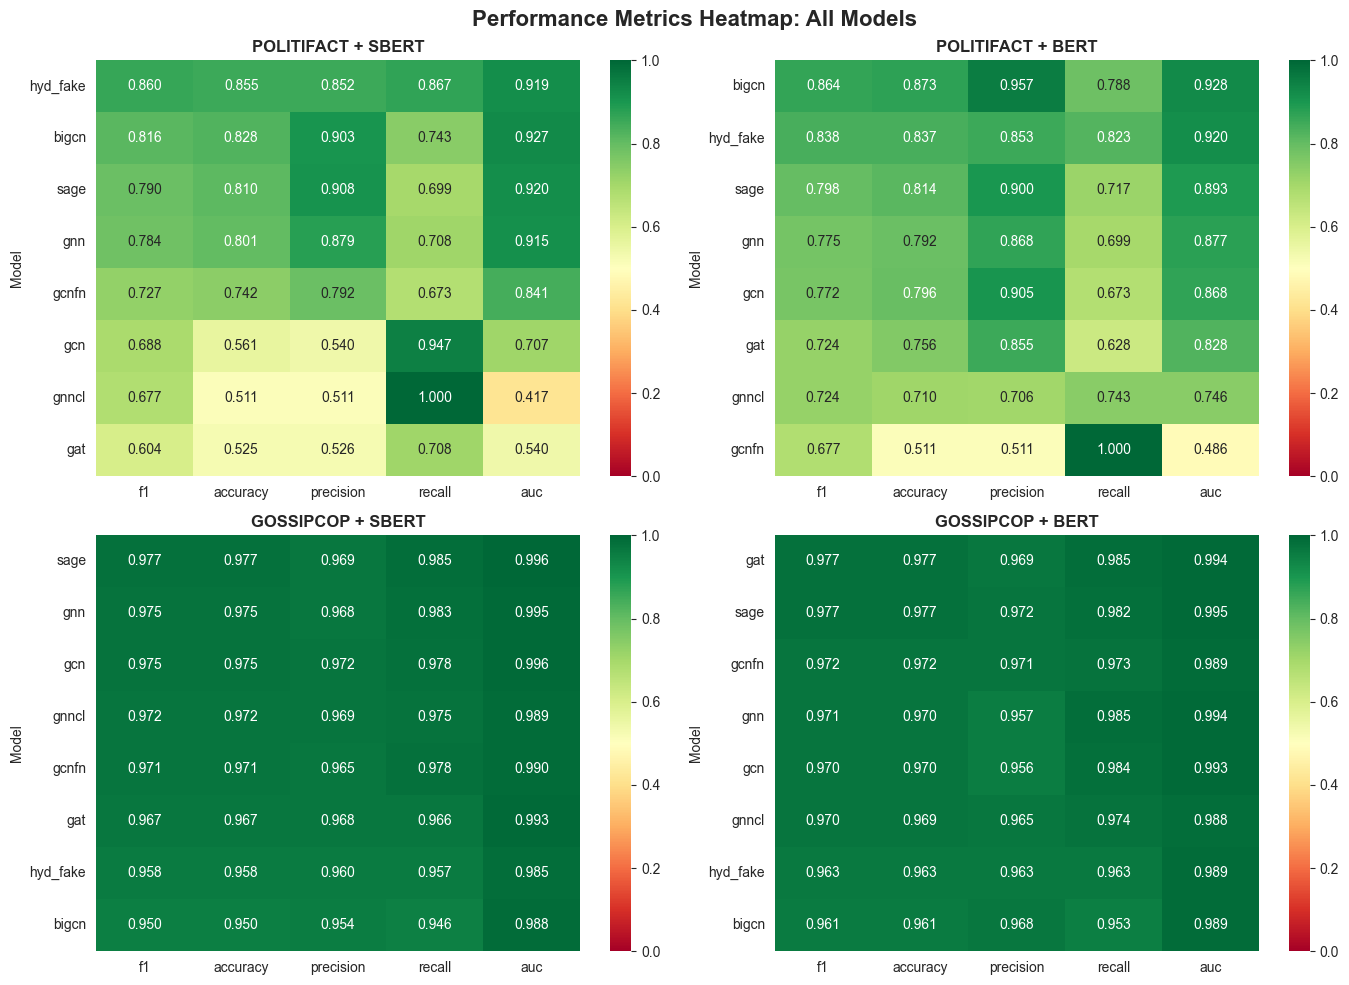

Saved: ../results/comparison_metrics_heatmap.png


In [10]:
# Heatmap: Models × Metrics for each Dataset+Encoder
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Metrics Heatmap: All Models', fontsize=16, fontweight='bold')

for idx, (dataset, encoder) in enumerate([(d, e) for d in DATASETS for e in ENCODERS]):
    ax = axes[idx // 2, idx % 2]
    
    df_subset = df_results[
        (df_results['dataset'] == dataset) & 
        (df_results['encoder'] == encoder)
    ].set_index('model')[metrics_to_compare].sort_values('f1', ascending=False)
    
    if len(df_subset) > 0:
        sns.heatmap(
            df_subset,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            cbar=True,
            ax=ax
        )
        ax.set_title(f'{dataset.upper()} + {encoder.upper()}', fontweight='bold')
        ax.set_ylabel('Model')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/comparison_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../results/comparison_metrics_heatmap.png")

## 9. Advanced Analysis: Model Performance Ranking

In [11]:
# Comprehensive ranking analysis
print("="*100)
print("OVERALL MODEL RANKING (All Datasets & Encoders)")
print("="*100)

# Calculate average performance across all combinations
ranking = df_results.groupby('model')[['f1', 'accuracy', 'precision', 'recall', 'auc']].mean().round(4)
ranking['avg_all_metrics'] = ranking.mean(axis=1)
ranking = ranking.sort_values('avg_all_metrics', ascending=False)

print("\nAverage Performance Across All Datasets & Encoders:")
print(ranking.to_string())

# Rank by F1 score
print("\n" + "-"*100)
print("TOP 5 MODELS BY F1 SCORE (Average across all combinations):")
print("-"*100)
f1_ranking = df_results.groupby('model')['f1'].mean().sort_values(ascending=False)
for i, (model, f1) in enumerate(f1_ranking.head(5).items(), 1):
    print(f"{i}. {model.upper():15s} - F1: {f1:.4f}")

# Best performance per dataset
print("\n" + "="*100)
print("BEST MODEL PER DATASET")
print("="*100)
for dataset in DATASETS:
    df_dataset = df_results[df_results['dataset'] == dataset]
    best_model = df_dataset.loc[df_dataset['f1'].idxmax()]
    print(f"\n{dataset.upper()}:")
    print(f"  Model: {best_model['model'].upper()}")
    print(f"  Encoder: {best_model['encoder'].upper()}")
    print(f"  F1: {best_model['f1']:.4f} | Acc: {best_model['accuracy']:.4f} | AUC: {best_model['auc']:.4f}")

# Best performance per encoder
print("\n" + "="*100)
print("BEST MODEL PER ENCODER")
print("="*100)
for encoder in ENCODERS:
    df_encoder = df_results[df_results['encoder'] == encoder]
    best_model = df_encoder.loc[df_encoder['f1'].idxmax()]
    print(f"\n{encoder.upper()}:")
    print(f"  Model: {best_model['model'].upper()}")
    print(f"  Dataset: {best_model['dataset'].upper()}")
    print(f"  F1: {best_model['f1']:.4f} | Acc: {best_model['accuracy']:.4f} | AUC: {best_model['auc']:.4f}")

OVERALL MODEL RANKING (All Datasets & Encoders)

Average Performance Across All Datasets & Encoders:
              f1  accuracy  precision  recall     auc  avg_all_metrics
model                                                                 
hyd_fake  0.9048    0.9035     0.9071  0.9026  0.9535          0.91430
bigcn     0.8976    0.9031     0.9457  0.8576  0.9582          0.91244
sage      0.8855    0.8945     0.9372  0.8458  0.9507          0.90274
gnn       0.8763    0.8846     0.9181  0.8438  0.9451          0.89358
gcn       0.8513    0.8256     0.8435  0.8955  0.8910          0.86138
gcnfn     0.8368    0.7991     0.8098  0.9057  0.8264          0.83556
gnncl     0.8356    0.7908     0.7879  0.9232  0.7847          0.82444
gat       0.8181    0.8061     0.8296  0.8219  0.8387          0.82288

----------------------------------------------------------------------------------------------------
TOP 5 MODELS BY F1 SCORE (Average across all combinations):
---------------------------

## 10. Model Consistency & Robustness Analysis

In [12]:
# Analyze model consistency across different conditions
print("="*100)
print("MODEL CONSISTENCY & ROBUSTNESS ANALYSIS")
print("="*100)

# Calculate variance in performance for each model
print("\nF1 Score Variance (Lower = More Consistent):")
print("-"*100)
consistency = df_results.groupby('model')['f1'].agg(['mean', 'std', 'min', 'max']).round(4)
consistency.columns = ['mean_f1', 'std_f1', 'min_f1', 'max_f1']
consistency['range'] = consistency['max_f1'] - consistency['min_f1']
consistency = consistency.sort_values('std_f1')

print(consistency.to_string())

# Models that perform well across all encoders
print("\n" + "="*100)
print("ENCODER ROBUSTNESS: Models maintaining performance across SBERT & BERT")
print("="*100)

for dataset in DATASETS:
    print(f"\n{dataset.upper()}:")
    df_dataset = df_results[df_results['dataset'] == dataset]
    
    # Get performance for each encoder
    sbert_perf = df_dataset[df_dataset['encoder'] == 'sbert'].set_index('model')['f1']
    bert_perf = df_dataset[df_dataset['encoder'] == 'bert'].set_index('model')['f1']
    
    # Calculate encoder consistency
    encoder_consistency = []
    for model in sbert_perf.index:
        if model in bert_perf.index:
            f1_diff = abs(bert_perf[model] - sbert_perf[model])
            avg_f1 = (sbert_perf[model] + bert_perf[model]) / 2
            pct_change = (f1_diff / sbert_perf[model]) * 100 if sbert_perf[model] > 0 else 0
            
            encoder_consistency.append({
                'model': model,
                'sbert_f1': sbert_perf[model],
                'bert_f1': bert_perf[model],
                'f1_diff': f1_diff,
                'pct_change': pct_change,
                'avg_f1': avg_f1
            })
    
    df_consistency = pd.DataFrame(encoder_consistency).sort_values('pct_change')
    print(df_consistency[['model', 'sbert_f1', 'bert_f1', 'f1_diff', 'pct_change']].to_string(index=False))

# Dataset robustness
print("\n" + "="*100)
print("DATASET ROBUSTNESS: Models maintaining performance across PolitiFact & GossipCop")
print("="*100)

for encoder in ENCODERS:
    print(f"\n{encoder.upper()}:")
    df_encoder = df_results[df_results['encoder'] == encoder]
    
    # Get performance for each dataset
    politifact_perf = df_encoder[df_encoder['dataset'] == 'politifact'].set_index('model')['f1']
    gossipcop_perf = df_encoder[df_encoder['dataset'] == 'gossipcop'].set_index('model')['f1']
    
    # Calculate dataset consistency
    dataset_consistency = []
    for model in politifact_perf.index:
        if model in gossipcop_perf.index:
            f1_diff = abs(gossipcop_perf[model] - politifact_perf[model])
            avg_f1 = (politifact_perf[model] + gossipcop_perf[model]) / 2
            pct_change = (f1_diff / politifact_perf[model]) * 100 if politifact_perf[model] > 0 else 0
            
            dataset_consistency.append({
                'model': model,
                'politifact_f1': politifact_perf[model],
                'gossipcop_f1': gossipcop_perf[model],
                'f1_diff': f1_diff,
                'pct_change': pct_change,
                'avg_f1': avg_f1
            })
    
    df_consistency = pd.DataFrame(dataset_consistency).sort_values('pct_change')
    print(df_consistency[['model', 'politifact_f1', 'gossipcop_f1', 'f1_diff', 'pct_change']].to_string(index=False))

MODEL CONSISTENCY & ROBUSTNESS ANALYSIS

F1 Score Variance (Lower = More Consistent):
----------------------------------------------------------------------------------------------------
          mean_f1  std_f1  min_f1  max_f1   range
model                                            
hyd_fake   0.9048  0.0653  0.8378  0.9632  0.1254
bigcn      0.8976  0.0697  0.8155  0.9605  0.1450
sage       0.8855  0.1057  0.7900  0.9770  0.1870
gnn        0.8763  0.1120  0.7745  0.9754  0.2009
gcn        0.8513  0.1443  0.6881  0.9753  0.2872
gcnfn      0.8368  0.1571  0.6766  0.9718  0.2952
gnncl      0.8356  0.1574  0.6766  0.9722  0.2956
gat        0.8181  0.1845  0.6038  0.9770  0.3732

ENCODER ROBUSTNESS: Models maintaining performance across SBERT & BERT

POLITIFACT:
   model  sbert_f1  bert_f1  f1_diff  pct_change
    sage  0.790000 0.798030 0.008030    1.016400
     gnn  0.784314 0.774510 0.009804    1.250000
hyd_fake  0.859649 0.837838 0.021811    2.537231
   bigcn  0.815534 0.864078 0.04

## 11. Metric Trade-off Analysis

In [13]:
# Analyze precision vs recall trade-offs
print("="*100)
print("PRECISION vs RECALL TRADE-OFF ANALYSIS")
print("="*100)

for dataset in DATASETS:
    for encoder in ENCODERS:
        print(f"\n{dataset.upper()} + {encoder.upper()}:")
        print("-"*100)
        
        df_subset = df_results[
            (df_results['dataset'] == dataset) & 
            (df_results['encoder'] == encoder)
        ].copy()
        
        # Calculate F1 as harmonic mean of precision and recall
        df_subset['precision_recall_ratio'] = df_subset['precision'] / (df_subset['recall'] + 1e-6)
        df_subset['metric_balance'] = np.abs(df_subset['precision'] - df_subset['recall'])
        
        # Sort by balance (lower is better balanced)
        df_subset = df_subset.sort_values('metric_balance')
        
        print("Models with Best Precision-Recall Balance:")
        print(df_subset[['model', 'precision', 'recall', 'f1', 'metric_balance']].head(3).to_string(index=False))
        
        print("\nModels with Precision > Recall (Conservative):")
        conservative = df_subset[df_subset['precision'] > df_subset['recall']]
        if len(conservative) > 0:
            print(conservative[['model', 'precision', 'recall', 'f1']].to_string(index=False))
        else:
            print("None")
        
        print("\nModels with Recall > Precision (Aggressive):")
        aggressive = df_subset[df_subset['recall'] > df_subset['precision']]
        if len(aggressive) > 0:
            print(aggressive[['model', 'precision', 'recall', 'f1']].to_string(index=False))
        else:
            print("None")

# Compare F1 vs AUC
print("\n" + "="*100)
print("F1 SCORE vs AUC-ROC CORRELATION")
print("="*100)

correlation = df_results[['f1', 'auc']].corr()
print(f"\nPearson Correlation (F1 vs AUC): {correlation.loc['f1', 'auc']:.4f}")

# Models with divergent F1 and AUC scores
df_results['f1_auc_diff'] = np.abs(df_results['f1'] - df_results['auc'])
print("\nModels with HIGH F1 but LOW AUC (Potential Overfitting to Class Distribution):")
high_divergence = df_results.nlargest(5, 'f1_auc_diff')
print(high_divergence[['model', 'encoder', 'dataset', 'f1', 'auc', 'f1_auc_diff']].to_string(index=False))

print("\nModels with LOW F1 but HIGH AUC (Potential Classification Threshold Issue):")
low_f1_high_auc = df_results[(df_results['f1'] < 0.7) & (df_results['auc'] > 0.85)]
if len(low_f1_high_auc) > 0:
    print(low_f1_high_auc[['model', 'encoder', 'dataset', 'f1', 'auc']].to_string(index=False))
else:
    print("None found")

PRECISION vs RECALL TRADE-OFF ANALYSIS

POLITIFACT + SBERT:
----------------------------------------------------------------------------------------------------
Models with Best Precision-Recall Balance:
   model  precision   recall       f1  metric_balance
hyd_fake   0.852174 0.867257 0.859649        0.015083
   gcnfn   0.791667 0.672566 0.727273        0.119100
   bigcn   0.903226 0.743363 0.815534        0.159863

Models with Precision > Recall (Conservative):
model  precision   recall       f1
gcnfn   0.791667 0.672566 0.727273
bigcn   0.903226 0.743363 0.815534
  gnn   0.879121 0.707965 0.784314
 sage   0.908046 0.699115 0.790000

Models with Recall > Precision (Aggressive):
   model  precision   recall       f1
hyd_fake   0.852174 0.867257 0.859649
     gat   0.526316 0.707965 0.603774
     gcn   0.540404 0.946903 0.688103
   gnncl   0.511312 1.000000 0.676647

POLITIFACT + BERT:
----------------------------------------------------------------------------------------------------


## 12. Advanced Visualizations: Scatter Plots & Correlations

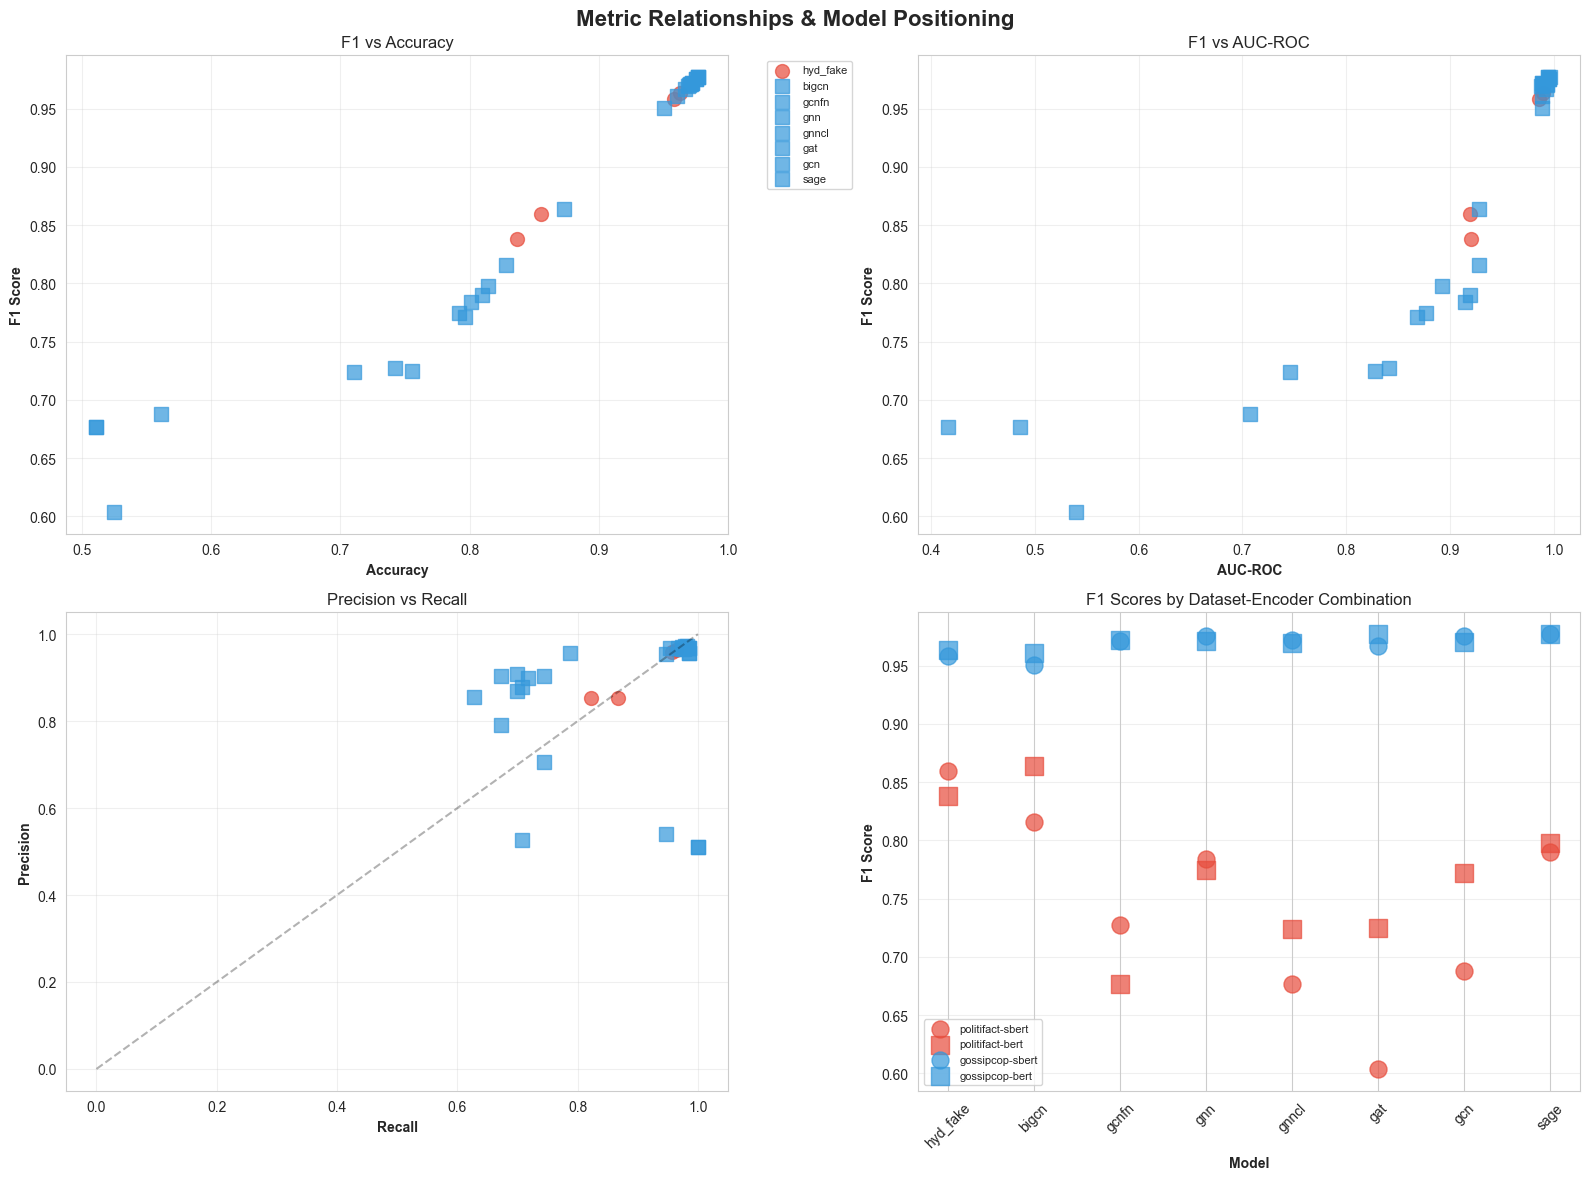

Saved: ../results/advanced_metric_analysis.png

METRIC CORRELATION MATRIX (All Results)
               f1  accuracy  precision  recall     auc
f1         1.0000    0.9586     0.8595  0.6455  0.8584
accuracy   0.9586    1.0000     0.9621  0.4032  0.9553
precision  0.8595    0.9621     1.0000  0.1758  0.9640
recall     0.6455    0.4032     0.1758  1.0000  0.2030
auc        0.8584    0.9553     0.9640  0.2030  1.0000


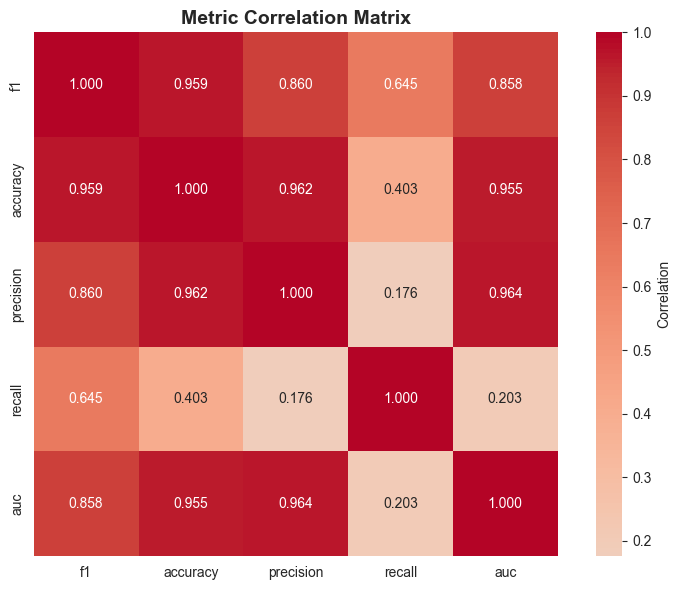

Saved: ../results/metric_correlation_matrix.png


In [14]:
# Scatter plots for metric relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Metric Relationships & Model Positioning', fontsize=16, fontweight='bold')

# Scatter 1: F1 vs Accuracy
ax = axes[0, 0]
for model in df_results['model'].unique():
    df_model = df_results[df_results['model'] == model]
    color = '#e74c3c' if model == 'hyd_fake' else '#3498db'
    marker = 'o' if model == 'hyd_fake' else 's'
    ax.scatter(df_model['accuracy'], df_model['f1'], label=model, alpha=0.7, s=100, color=color, marker=marker)
ax.set_xlabel('Accuracy', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 vs Accuracy')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Scatter 2: F1 vs AUC
ax = axes[0, 1]
for model in df_results['model'].unique():
    df_model = df_results[df_results['model'] == model]
    color = '#e74c3c' if model == 'hyd_fake' else '#3498db'
    marker = 'o' if model == 'hyd_fake' else 's'
    ax.scatter(df_model['auc'], df_model['f1'], label=model, alpha=0.7, s=100, color=color, marker=marker)
ax.set_xlabel('AUC-ROC', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 vs AUC-ROC')
ax.grid(True, alpha=0.3)

# Scatter 3: Precision vs Recall
ax = axes[1, 0]
for model in df_results['model'].unique():
    df_model = df_results[df_results['model'] == model]
    color = '#e74c3c' if model == 'hyd_fake' else '#3498db'
    marker = 'o' if model == 'hyd_fake' else 's'
    ax.scatter(df_model['recall'], df_model['precision'], label=model, alpha=0.7, s=100, color=color, marker=marker)
ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision vs Recall')
ax.grid(True, alpha=0.3)
# Add diagonal line (perfect balance)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Balance')

# Scatter 4: Dataset vs Encoder Effect
ax = axes[1, 1]
dataset_colors = {'politifact': '#e74c3c', 'gossipcop': '#3498db'}
encoder_markers = {'sbert': 'o', 'bert': 's'}

for dataset in DATASETS:
    for encoder in ENCODERS:
        df_subset = df_results[(df_results['dataset'] == dataset) & (df_results['encoder'] == encoder)]
        ax.scatter(df_subset['model'].astype(str), df_subset['f1'], 
                  color=dataset_colors[dataset], marker=encoder_markers[encoder], 
                  s=150, alpha=0.7, label=f'{dataset}-{encoder}')

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 Scores by Dataset-Encoder Combination')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/advanced_metric_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../results/advanced_metric_analysis.png")

# Correlation matrix
print("\n" + "="*100)
print("METRIC CORRELATION MATRIX (All Results)")
print("="*100)

correlation_matrix = df_results[['f1', 'accuracy', 'precision', 'recall', 'auc']].corr().round(4)
print(correlation_matrix.to_string())

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Metric Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../results/metric_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../results/metric_correlation_matrix.png")

## 13. Performance Gap & Comparative Analysis

PERFORMANCE GAP ANALYSIS

HYD-FAKE ADVANTAGE OVER BASELINES:
----------------------------------------------------------------------------------------------------

POLITIFACT + SBERT:
baseline  baseline_f1  hyd_fake_f1      gap   gap_pct
     GAT     0.603774     0.859649 0.255876 42.379386
   GNNCL     0.676647     0.859649 0.183002 27.045490
     GCN     0.688103     0.859649 0.171546 24.930316
   GCNFN     0.727273     0.859649 0.132376 18.201754
     GNN     0.784314     0.859649 0.075335  9.605263
    SAGE     0.790000     0.859649 0.069649  8.816345
   BIGCN     0.815534     0.859649 0.044115  5.409357
  Summary: Avg Gap=+0.1331, Max=+0.2559, Min=+0.0441

POLITIFACT + BERT:
baseline  baseline_f1  hyd_fake_f1       gap   gap_pct
   GCNFN     0.676647     0.837838  0.161191 23.822052
   GNNCL     0.724138     0.837838  0.113700 15.701416
     GAT     0.724490     0.837838  0.113348 15.645223
     GCN     0.771574     0.837838  0.066264  8.588193
     GNN     0.774510     0.837838  0

C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_23284\708932471.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_model, labels=sorted(models), patch_artist=True)
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_23284\708932471.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_dataset, labels=sorted(datasets), patch_artist=True)


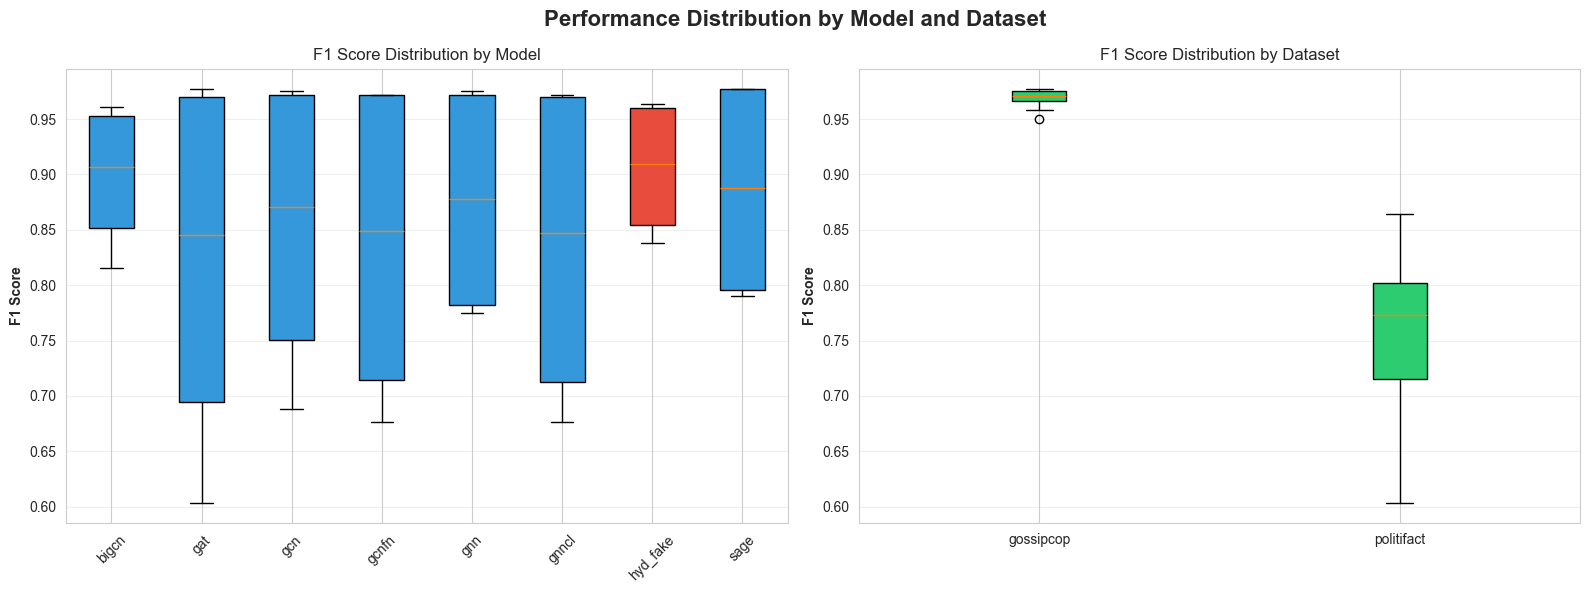


Saved: ../results/performance_distribution_analysis.png


In [15]:
# Analyze performance gaps between models
print("="*100)
print("PERFORMANCE GAP ANALYSIS")
print("="*100)

# Gap between HyD-Fake and baselines
print("\nHYD-FAKE ADVANTAGE OVER BASELINES:")
print("-"*100)

for dataset in DATASETS:
    for encoder in ENCODERS:
        print(f"\n{dataset.upper()} + {encoder.upper()}:")
        
        df_subset = df_results[
            (df_results['dataset'] == dataset) & 
            (df_results['encoder'] == encoder)
        ]
        
        hyd_fake_row = df_subset[df_subset['model'] == 'hyd_fake']
        baseline_rows = df_subset[df_subset['model'] != 'hyd_fake']
        
        if len(hyd_fake_row) > 0 and len(baseline_rows) > 0:
            hyd_f1 = hyd_fake_row['f1'].values[0]
            
            # Gaps vs each baseline
            gaps = []
            for _, baseline in baseline_rows.iterrows():
                gap = hyd_f1 - baseline['f1']
                gap_pct = (gap / baseline['f1']) * 100 if baseline['f1'] > 0 else 0
                gaps.append({
                    'baseline': baseline['model'].upper(),
                    'baseline_f1': baseline['f1'],
                    'hyd_fake_f1': hyd_f1,
                    'gap': gap,
                    'gap_pct': gap_pct
                })
            
            df_gaps = pd.DataFrame(gaps).sort_values('gap', ascending=False)
            print(df_gaps[['baseline', 'baseline_f1', 'hyd_fake_f1', 'gap', 'gap_pct']].to_string(index=False))
            
            # Summary stats
            avg_gap = df_gaps['gap'].mean()
            max_gap = df_gaps['gap'].max()
            min_gap = df_gaps['gap'].min()
            print(f"  Summary: Avg Gap={avg_gap:+.4f}, Max={max_gap:+.4f}, Min={min_gap:+.4f}")

# Best vs Worst performer gap
print("\n" + "="*100)
print("BEST vs WORST PERFORMER GAPS (Per Dataset+Encoder)")
print("="*100)

for dataset in DATASETS:
    for encoder in ENCODERS:
        df_subset = df_results[
            (df_results['dataset'] == dataset) & 
            (df_results['encoder'] == encoder)
        ].sort_values('f1')
        
        best = df_subset.iloc[-1]
        worst = df_subset.iloc[0]
        gap = best['f1'] - worst['f1']
        gap_pct = (gap / worst['f1']) * 100 if worst['f1'] > 0 else 0
        
        print(f"\n{dataset.upper()} + {encoder.upper()}:")
        print(f"  Best:  {best['model'].upper():10s} - F1: {best['f1']:.4f}")
        print(f"  Worst: {worst['model'].upper():10s} - F1: {worst['f1']:.4f}")
        print(f"  Gap:   {gap:+.4f} ({gap_pct:+.2f}%)")

# Statistical summary
print("\n" + "="*100)
print("STATISTICAL SUMMARY")
print("="*100)

print("\nF1 Score Statistics by Model:")
f1_stats = df_results.groupby('model')['f1'].describe().round(4)
print(f1_stats[['count', 'mean', 'std', 'min', '50%', 'max']].to_string())

print("\n\nF1 Score Statistics by Dataset:")
dataset_stats = df_results.groupby('dataset')['f1'].describe().round(4)
print(dataset_stats[['count', 'mean', 'std', 'min', '50%', 'max']].to_string())

print("\n\nF1 Score Statistics by Encoder:")
encoder_stats = df_results.groupby('encoder')['f1'].describe().round(4)
print(encoder_stats[['count', 'mean', 'std', 'min', '50%', 'max']].to_string())

# Visualization: Performance gap comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Distribution by Model and Dataset', fontsize=16, fontweight='bold')

# Box plot by model
ax = axes[0]
models = df_results['model'].unique()
data_by_model = [df_results[df_results['model'] == m]['f1'].values for m in sorted(models)]
bp = ax.boxplot(data_by_model, labels=sorted(models), patch_artist=True)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#e74c3c' if sorted(models)[i] == 'hyd_fake' else '#3498db')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 Score Distribution by Model')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# Box plot by dataset
ax = axes[1]
datasets = df_results['dataset'].unique()
data_by_dataset = [df_results[df_results['dataset'] == d]['f1'].values for d in sorted(datasets)]
bp = ax.boxplot(data_by_dataset, labels=sorted(datasets), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#2ecc71')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('F1 Score Distribution by Dataset')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/performance_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: ../results/performance_distribution_analysis.png")

## 14. Export Results to CSV

In [16]:
# Export results
csv_path = '../results/model_comparison_results.csv'
df_results.to_csv(csv_path, index=False)
print(f"Exported results to: {csv_path}")

# Export summary statistics
summary_path = '../results/model_comparison_summary.txt'
with open(summary_path, 'w') as f:
    f.write("COMPREHENSIVE MODEL COMPARISON - SUMMARY REPORT\n")
    f.write("="*100 + "\n")
    f.write(f"Generated from comprehensive analysis notebook\n")
    f.write(f"Datasets: {', '.join(DATASETS)}\n")
    f.write(f"Encoders: {', '.join(ENCODERS)}\n")
    f.write(f"Models: {', '.join(ALL_MODELS)}\n")
    f.write("="*100 + "\n\n")
    f.write("DETAILED RESULTS:\n")
    f.write(df_results.to_string())

print(f"Exported summary to: {summary_path}")

# Create analysis report
report_path = '../results/ANALYSIS_REPORT.md'
with open(report_path, 'w') as f:
    f.write("# Comprehensive Model Comparison Analysis Report\n\n")
    f.write("## Overview\n")
    f.write(f"- Total Results: {len(df_results)} (Models: {len(df_results['model'].unique())}, ")
    f.write(f"Datasets: {len(DATASETS)}, Encoders: {len(ENCODERS)})\n")
    f.write(f"- Best Overall F1: {df_results['f1'].max():.4f}\n")
    f.write(f"- Average F1: {df_results['f1'].mean():.4f}\n")
    f.write(f"- Worst F1: {df_results['f1'].min():.4f}\n\n")
    
    f.write("## Key Findings\n\n")

    # Top 3 models
    top_models = df_results.groupby('model')['f1'].mean().nlargest(3)
    f.write("### Top 3 Models by Average F1:\n")
    for i, (model, f1) in enumerate(top_models.items(), 1):
        f.write(f"{i}. {model.upper()}: {f1:.4f}\n")
    
    f.write("\n### Generated Visualizations:\n")
    f.write("- comparison_f1_scores.png (F1 scores across all models)\n")
    f.write("- comparison_metrics_heatmap.png (All metrics heatmap)\n")
    f.write("- advanced_metric_analysis.png (Scatter plots & relationships)\n")
    f.write("- metric_correlation_matrix.png (Correlation analysis)\n")
    f.write("- performance_distribution_analysis.png (Box plots & distributions)\n")
    
    f.write("\n### Generated Data Files:\n")
    f.write("- model_comparison_results.csv (Raw results)\n")
    f.write("- model_comparison_summary.txt (Summary statistics)\n")

print(f"Exported analysis report to: {report_path}")
print("\n" + "="*100)
print("ALL EXPORTS COMPLETE")
print("="*100)

Exported results to: ../results/model_comparison_results.csv
Exported summary to: ../results/model_comparison_summary.txt
Exported analysis report to: ../results/ANALYSIS_REPORT.md

ALL EXPORTS COMPLETE
